In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.insert(0, "../func_py/")
import infer_gbm as gbm
import data_utils as dtu

metadata = pd.read_csv('metadata/metadata.tsv', sep='\t', index_col=0)

### Studying the variance of the likelihood varying the prior of the importance sampling

We vary the two parameters of the import function of the MC integration, which is chosen as a two-parameter gamma distribution: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html.
Note that this distribution is over the log-counts $x=\log n$.
The two parameters that we vary are the parameter $a$ of the gamma and the standard deviation through a factor $c$.
This factor rescales the standard deviation with an estimate of the largest possible value of $x_{max} = \log n_{max}$ that can be sampled.
More precisely
$$
\sigma = \frac{x_{max}}{c} 
$$

In [4]:
# Choose the inference setting

# List containing the inference settings. Each element is composed by:
# - setting label patinet-ntimepoints
# - list of samples used in the inference
# - delta times that separate the samples in years
pairs_and_dts = [
    ('AT', ('AT_t1_mem', 'AT_t2_mem', 'AT_t3_mem'), [1/12, 11/12]),
    ('D01', ('D01_t2_mem', 'D01_t3_mem'), [11/12]),
    ('IM', ('IM_t1_mem', 'IM_t2_mem', 'IM_t3_mem'), [1/12, 11/12]),
    ('IZ', ('IZ_t1_mem', 'IZ_t2_mem', 'IZ_t3_mem'), [1/12, 11/12]),
]
# Choose the inference setting from the list above
label, samples, dtimes = pairs_and_dts[2]

print('Running the notebook for the setting', label)
# Dataframe of sparse counts 
sp_counts = dtu.import_and_build_sparse_counts(samples, 'family', 'count')
# Noise parameters of the negative binomial
a_negbin = dtu.read_noise_negbin_a('inference/noise/', samples)

Running the notebook for the setting IM
count label not found, setting the counts to 1
count label not found, setting the counts to 1
count label not found, setting the counts to 1
one or more samples do not have a lerned model, the parameter is set as the average of the others


### Studying the prior gamma function
We vary the two parameters of the import function of the MC integration, which is chosen as a gamma distribution.
We vary the parameter $a$ of the gamma and a factor $c$ that rescales the standard deviation with an estimate of the largest possible value of $x = \log n$ that can be sampled.
More precisely
$$
\sigma = \frac{x_{max}}{c} 
$$

The pair of parameters $a$ and $c$ are then used as the last argument of pairs_and_dts.like_f_at_prior

In [5]:
# Parameters to set

R = 50 # Number of replicates
n_eval = 20000 # number of MC points to evaluate the likelihood
gamma_as = [3, 5, 7] # Parameter a of the gamma to vary
std_factors = np.logspace(0.2, 1, 10) # Parameter c of the gamma to vary
tau, theta, M_tot, n0 = 15, 10, 10**7, 20 # Other parameter of the GBM to set (around the optimum)

infer_pars = gbm.gbm_infer_pars(dtimes, M_tot, n0, 1, n_eval=n_eval, prior_pars=[0,0])

In [6]:
max_n1 = max(sp_counts.n1.values)
M1 = np.sum(sp_counts.n1 * sp_counts.occ)
like_f_at_prior = lambda x : gbm.MC_gbm_full_ll(sp_counts, tau, theta, infer_pars, x)

avs, stds = gbm.scan_gamma_prior_std(gamma_as, std_factors, max_n1, M1, infer_pars.M_tot, like_f_at_prior, R=R)

  0%|          | 0/30 [00:00<?, ?it/s]

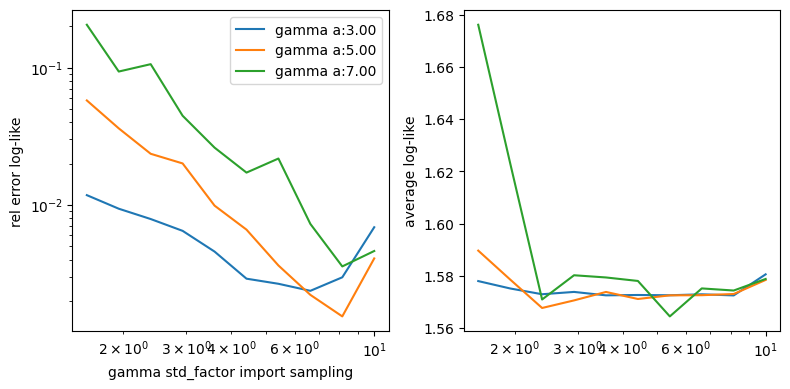

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))

ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('gamma std_factor import sampling')
ax1.set_ylabel('rel error log-like')
ax2.set_ylabel('average log-like')
for i, a in enumerate(gamma_as):
    ax1.plot(std_factors, np.abs(stds[i]), label='gamma a:%3.2f'%a)
    ax2.plot(std_factors, np.abs(avs[i]), label='gamma a:%3.2f'%a)
ax1.legend()

plt.tight_layout()